✅ Đã nạp thành công dữ liệu:
- ORDERS: 139548 dòng, 8 cột
- ORDER_ITEM: 273743 dòng, 6 cột

1. CÁC THƯỚC ĐO (MEASURES) GỐC ĐƯỢC TRÍCH XUẤT:
- Bảng ORDERS     : order_id, order_date
- Bảng ORDER_ITEM : order_id, quantity, unit_price, discount_amount
✅ Đã huấn luyện và dự báo thành công 6 tháng tiếp theo:
month_date  t  forecast_revenue
2014-06-30 24      1.366173e+08
2014-07-31 25      1.370117e+08
2014-08-31 26      1.374061e+08
2014-09-30 27      1.378005e+08
2014-10-31 28      1.381948e+08
2014-11-30 29      1.385892e+08

3. BỘ CHỈ SỐ HIỆU SUẤT (KPI) ĐÁNH GIÁ MÔ HÌNH & KINH DOANH:
- KPI 1 [MAE]          : 32,179,709.54 (Sai số tiền tệ trung bình mỗi tháng)
- KPI 2 [RMSE]         : 39,015,410.95 (Sai số trung bình có phạt nặng độ lệch lớn)
- KPI 3 [MAPE]         : 25.73% (Tỷ lệ sai số phần trăm so với thực tế)
- KPI 4 [R-Squared]    : 0.0045 (0.45% phương sai được giải thích bởi xu hướng)
- KPI 5 [Forecast Gap] : -21.07% (Mức thay đổi nhu cầu dự kiến để chuẩn bị nhập hàng)


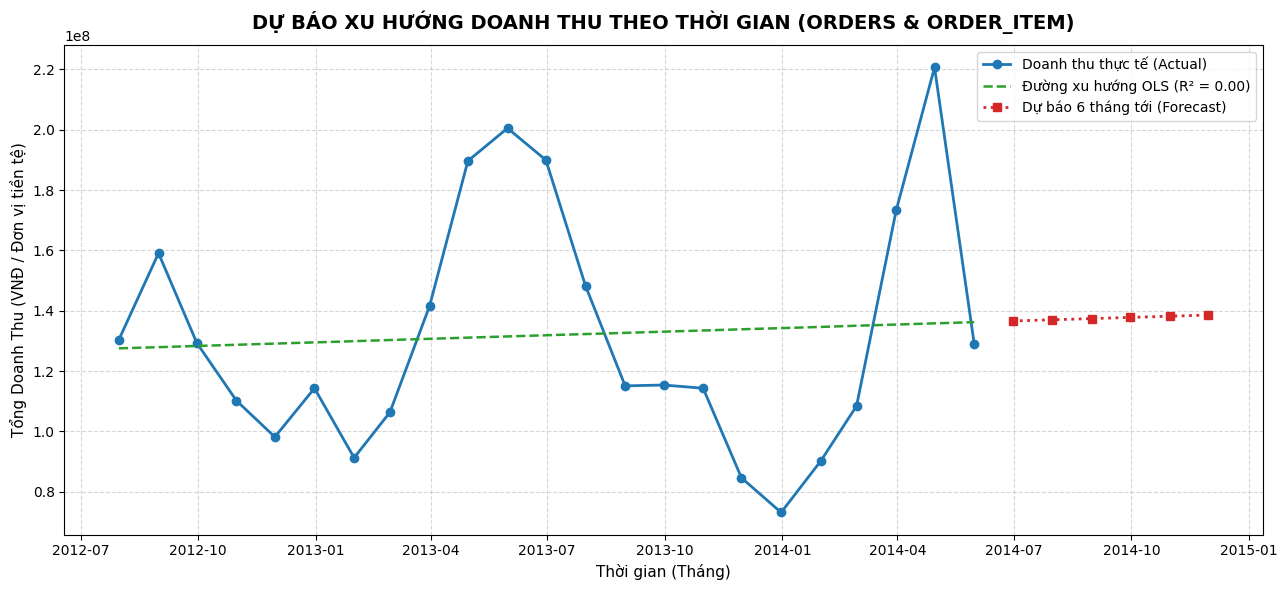

In [ ]:
# ==============================================================================
# PROBLEM STATEMENT 5: DỰ BÁO XU HƯỚNG DOANH THU CHO CÁC THÁNG TIẾP THEO
# Dữ liệu sử dụng: ORDERS.csv và ORDER_ITEM.csv
# Kiến trúc triển khai: THƯỚC ĐO (MEASURE) -> ĐỘ ĐO (METRIC) -> CHỈ SỐ (KPI)
# ==============================================================================

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
import statsmodels.api as sm

# ------------------------------------------------------------------------------
# BƯỚC 0: NẠP DỮ LIỆU TỪ HAI BẢNG QUAN HỆ (ORDERS & ORDER_ITEM)
# ------------------------------------------------------------------------------
orders_file = 'ORDERS.csv'
order_item_file = 'ORDER_ITEM.csv'

# Tự động tìm kiếm nếu file nằm trong Google Drive hoặc thư mục tải lên của Colab
for base_dir in ['', '/content/', '/content/drive/MyDrive/']:
  if os.path.exists(os.path.join(base_dir, 'ORDERS.csv')):
    orders_file = os.path.join(base_dir, 'ORDERS.csv')
  if os.path.exists(os.path.join(base_dir, 'ORDER_ITEM.csv')):
    order_item_file = os.path.join(base_dir, 'ORDER_ITEM.csv')

df_orders = pd.read_csv(orders_file)
df_items = pd.read_csv(order_item_file)

print('✅ Đã nạp thành công dữ liệu:')
print(f"- ORDERS: {df_orders.shape[0]} dòng, {df_orders.shape[1]} cột")
print(f"- ORDER_ITEM: {df_items.shape[0]} dòng, {df_items.shape[1]} cột")

# ==============================================================================
# TẦNG 1: THƯỚC ĐO (MEASURES)
# Các cột số liệu định lượng gốc thu thập trực tiếp từ hai bảng quan hệ
# ==============================================================================
# Chuẩn hóa tên cột về chữ thường để tránh lỗi viết hoa/thường khác nhau
df_orders.columns = df_orders.columns.str.lower()
df_items.columns = df_items.columns.str.lower()

# Các trường Thước đo (Measures) chính:
# - order_date      : Mốc thời gian giao dịch (từ bảng ORDERS)
# - quantity        : Số lượng mua trên từng dòng đơn hàng (từ bảng ORDER_ITEM)
# - unit_price      : Đơn giá sản phẩm tại thời điểm bán (từ bảng ORDER_ITEM)
# - discount_amount : Giá trị/mức chiết khấu giảm trực tiếp (từ bảng ORDER_ITEM)

if 'discount_amount' not in df_items.columns:
  df_items['discount_amount'] = 0.0

print('\n' + '=' * 65)
print('1. CÁC THƯỚC ĐO (MEASURES) GỐC ĐƯỢC TRÍCH XUẤT:')
print('- Bảng ORDERS     : order_id, order_date')
print('- Bảng ORDER_ITEM : order_id, quantity, unit_price, discount_amount')
print('=' * 65)

# Kết hợp (JOIN) 2 bảng theo khóa chính / khóa ngoại order_id
df_merged = pd.merge(
    df_items[['order_id', 'quantity', 'unit_price', 'discount_amount']],
    df_orders[['order_id', 'order_date']],
    on='order_id',
    how='inner',
)

# Chuyển đổi định dạng thời gian
df_merged['order_date'] = pd.to_datetime(df_merged['order_date'])

# ==============================================================================
# TẦNG 2: ĐỘ ĐO (METRICS)
# Các đại lượng tính toán, tổng hợp chuỗi thời gian và giá trị ước lượng của mô hình
# ==============================================================================

# 2.1. Doanh thu thực tế từng dòng sản phẩm (sau khi trừ chiết khấu)
df_merged['item_revenue'] = (
    df_merged['quantity'] * df_merged['unit_price']
) - df_merged['discount_amount']

# 2.2. Gom nhóm theo chuỗi thời gian: Doanh thu thực tế từng tháng (y_t)
monthly_rev = (
    df_merged.set_index('order_date')
    .resample('ME')['item_revenue']
    .sum()
    .reset_index()
)
monthly_rev.rename(
    columns={'order_date': 'month_date', 'item_revenue': 'actual_revenue'},
    inplace=True,
)

# 2.3. Chỉ số thứ tự thời gian tuần tự (t = 1, 2, ..., n)
monthly_rev['t'] = np.arange(1, len(monthly_rev) + 1)

# ==============================================================================
# 2.4. HUẤN LUYỆN MÔ HÌNH HỒI QUY XU HƯỚNG TUYẾN TÍNH (OLS)
# y_hat = w0 + w1 * t
# ==============================================================================
# Tạo DataFrame X rõ ràng với cột 'const' và 't'
X = pd.DataFrame({'const': 1.0, 't': monthly_rev['t']})
y = monthly_rev['actual_revenue']

model = sm.OLS(y, X).fit()

# 2.5. Doanh thu dự báo quá khứ và Phần dư sai số (Residual e = y - y_hat)
monthly_rev['fitted_revenue'] = model.predict(X)
monthly_rev['residual_e'] = (
    monthly_rev['actual_revenue'] - monthly_rev['fitted_revenue']
)

# 2.6. Dự báo doanh thu cho 6 tháng tiếp theo (Khắc phục triệt để lỗi shape)
n_future_months = 6
last_recorded_month = monthly_rev['month_date'].max()
future_dates = pd.date_range(
    start=last_recorded_month + pd.DateOffset(months=1),
    periods=n_future_months,
    freq='ME',
)
future_t = np.arange(
    len(monthly_rev) + 1, len(monthly_rev) + n_future_months + 1
)

# Tạo future_X có cấu trúc DataFrame giống hệt X huấn luyện
future_X = pd.DataFrame({'const': 1.0, 't': future_t})

# Thực hiện dự báo an toàn
future_predictions = model.predict(future_X)

df_forecast = pd.DataFrame({
    'month_date': future_dates,
    't': future_t,
    'forecast_revenue': future_predictions,
})

print('✅ Đã huấn luyện và dự báo thành công 6 tháng tiếp theo:')
print(df_forecast.to_string(index=False))





# ==============================================================================
# TẦNG 3: BỘ CHỈ SỐ HIỆU SUẤT (KPI)
# Các chỉ số cấp cao đo lường chất lượng dự báo và phục vụ kế hoạch nhập hàng
# ==============================================================================
y_actual = monthly_rev['actual_revenue']
y_pred = monthly_rev['fitted_revenue']

# 3.1. Sai số tuyệt đối trung bình (MAE)
kpi_mae = mean_absolute_error(y_actual, y_pred)

# 3.2. Sai số căn bậc hai trung bình (RMSE)
kpi_rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

# 3.3. Tỷ lệ sai số phần trăm tuyệt đối trung bình (MAPE)
kpi_mape = mean_absolute_percentage_error(y_actual, y_pred) * 100

# 3.4. Hệ số xác định (R-squared / R²)
kpi_r2 = r2_score(y_actual, y_pred)

# 3.5. Forecast Gap % (Tỷ lệ tăng trưởng doanh thu dự báo so với 3 tháng gần nhất)
current_avg_sales = y_actual.tail(3).mean()
forecast_avg_sales = future_predictions.mean()
kpi_forecast_gap = (
    (forecast_avg_sales - current_avg_sales) / current_avg_sales
) * 100

print('\n3. BỘ CHỈ SỐ HIỆU SUẤT (KPI) ĐÁNH GIÁ MÔ HÌNH & KINH DOANH:')
print(
    f"- KPI 1 [MAE]          : {kpi_mae:,.2f} (Sai số tiền tệ trung bình mỗi"
    " tháng)"
)
print(
    f"- KPI 2 [RMSE]         : {kpi_rmse:,.2f} (Sai số trung bình có phạt nặng"
    " độ lệch lớn)"
)
print(
    f"- KPI 3 [MAPE]         : {kpi_mape:.2f}% (Tỷ lệ sai số phần trăm so với"
    " thực tế)"
)
print(
    f"- KPI 4 [R-Squared]    : {kpi_r2:.4f} ({kpi_r2*100:.2f}% phương sai được"
    " giải thích bởi xu hướng)"
)
print(
    f"- KPI 5 [Forecast Gap] : {kpi_forecast_gap:+.2f}% (Mức thay đổi nhu cầu dự"
    " kiến để chuẩn bị nhập hàng)"
)
print('=' * 65)

# ------------------------------------------------------------------------------
# BƯỚC 4: TRỰC QUAN HÓA XU HƯỚNG VÀ DỰ BÁO DOANH THU TRÊN GOOGLE COLAB
# ------------------------------------------------------------------------------
plt.figure(figsize=(13, 6))

# Đường doanh thu thực tế
plt.plot(
    monthly_rev['month_date'],
    monthly_rev['actual_revenue'],
    marker='o',
    color='#1f77b4',
    linewidth=2,
    label='Doanh thu thực tế (Actual)',
)

# Đường hồi quy xu hướng (Fitted)
plt.plot(
    monthly_rev['month_date'],
    monthly_rev['fitted_revenue'],
    '--',
    color='#2ca02c',
    linewidth=1.8,
    label=f'Đường xu hướng OLS (R² = {kpi_r2:.2f})',
)

# Đường dự báo tương lai 6 tháng
plt.plot(
    df_forecast['month_date'],
    df_forecast['forecast_revenue'],
    marker='s',
    linestyle=':',
    color='#d62728',
    linewidth=2,
    label='Dự báo 6 tháng tới (Forecast)',
)

plt.title(
    'DỰ BÁO XU HƯỚNG DOANH THU THEO THỜI GIAN (ORDERS & ORDER_ITEM)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
plt.xlabel('Thời gian (Tháng)', fontsize=11)
plt.ylabel('Tổng Doanh Thu (VNĐ / Đơn vị tiền tệ)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()